## **Peramalan Kadar NO2 di Daerah Jombang**

### Latar Belakang
Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO₂), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

### 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.


Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .



Untuk menuliskan code Python untuk mengambil data, silahkan kunjungi halaman https://dataspace.copernicus.eu/analyse/jupyterlab, klik Access JupyterLab, scroll kebawah sedikit …, lalu pilih Python 3 (ipykernel)


### 2. Instalasi Library OpenEO

Pada tahap ini dilakukan instalasi library OpenEO yang digunakan untuk mengakses dan mengambil data penginderaan jauh dari Copernicus Data Space Ecosystem. Library ini memungkinkan pengguna untuk melakukan pemrosesan data satelit secara langsung melalui layanan cloud.

In [1]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


### 3. Koneksi ke Copernicus Data Space dan Pengambilan Data

Tahap ini bertujuan untuk menghubungkan Python dengan layanan Copernicus Data Space. Setelah koneksi berhasil dilakukan, ditentukan Area of Interest (AOI) berupa wilayah Jombang menggunakan koordinat geografis.

Data yang digunakan berasal dari satelit Sentinel-5P dengan parameter Nitrogen Dioxide (NO₂). Selanjutnya dilakukan proses pengunduhan data dan penyimpanan ke dalam format NetCDF (.nc) untuk dianalisis lebih lanjut.

In [2]:
import openeo

In [4]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=JZJB-UDWJ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [5]:
aoi = {
  "type": "FeatureCollection",
  "features": [{
    "type": "Feature",
    "properties": {},
    "geometry": {
      "type": "Polygon",
      "coordinates": [[
        [112.20429079519005, -7.451129197684509],
        [112.3423047, -7.4537385],
        [112.332206, -7.668665],
        [112.193326, -7.6626909],
        [112.20429079519005, -7.451129197684509]
      ]]
    }
  }]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-06-03", "2026-06-03"],
    spatial_extent={
        "west": 112.193326,
        "south": -7.668665,
        "east": 112.3423047,
        "north": -7.451129
    },
    bands=["NO2"]
)

s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

In [6]:
job = s5post.execute_batch(title="NO2 in Jombangg", outputfile="NO2Jombangg.nc")

0:00:00 Job 'j-2606030733164591a86828639075f9be': send 'start'
0:00:38 Job 'j-2606030733164591a86828639075f9be': queued (progress 0%)
0:00:43 Job 'j-2606030733164591a86828639075f9be': queued (progress 0%)
0:00:50 Job 'j-2606030733164591a86828639075f9be': queued (progress 0%)
0:00:58 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:01:08 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:01:21 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:01:36 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:01:56 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:02:20 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:02:50 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:03:27 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:04:14 Job 'j-2606030733164591a86828639075f9be': running (progress N/A)
0:05:12 Job 'j-2606030733164591a86828639075f9be': running (progress

### 4. Instalasi Library NetCDF4

Data hasil unduhan dari Copernicus tersimpan dalam format NetCDF (.nc). Oleh karena itu diperlukan library NetCDF4 agar file dapat dibaca dan diproses menggunakan Python.

In [9]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.7 MB/s eta 0:00:00


### 5. Membaca Data NO₂ dari File NetCDF

Pada tahap ini file NetCDF dibuka menggunakan library NetCDF4. Selanjutnya dilakukan identifikasi variabel yang tersedia pada dataset, pengambilan data NO₂, serta konversi data waktu menjadi format tanggal agar lebih mudah dianalisis.

In [10]:
import netCDF4
import os

print("File di folder saat ini:")
print(os.listdir())

file_path = "NO2Jombangg.nc"

ds = netCDF4.Dataset(file_path)

print("📦 Variabel dalam file:")
print(ds.variables.keys())

no2 = ds.variables["NO2"][:]
time = ds.variables["t"][:]

try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

print("Tipe data NO2:", type(no2))
print("Jumlah record NO2:", len(no2))
print("Panjang data per baris:", len(no2[0]))
print("Panjang data per data:", len(no2[0][0]))
print("Contoh nilai NO2 pertama:", no2[0][0][0])

File di folder saat ini:
['.config', 'NO2Jombangg.nc', 'sample_data']
📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
Tipe data NO2: <class 'numpy.ma.MaskedArray'>
Jumlah record NO2: 1090
Panjang data per baris: 7
Panjang data per data: 3
Contoh nilai NO2 pertama: 3.3581906e-05


### 6. Menampilkan Contoh Data

Tahap ini digunakan untuk memastikan bahwa data berhasil dibaca dengan benar. Beberapa nilai awal ditampilkan sebagai proses validasi sebelum dilakukan pengolahan lebih lanjut.

In [11]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[3.358190588187426e-05 3.358190588187426e-05 3.297527655377053e-05]
 [6.355073128361255e-05 6.355073128361255e-05 2.8336973628029227e-05]
 [3.3966382034122944e-05 -- 5.4748874390497804e-05]
 [3.1374074751511216e-05 -- 5.4748874390497804e-05]
 [2.9667720809811726e-05 2.2316520698950626e-05 --]
 [-- -- --]
 [-- -- --]]
[[4.244859155733138e-05 3.3408741728635505e-05 --]
 [6.346201553242281e-05 -- --]
 [6.346201553242281e-05 4.9529640818946064e-05 --]
 [5.868198786629364e-05 4.9529640818946064e-05 --]
 [3.305020072730258e-05 3.226722401450388e-05 4.927519694319926e-05]
 [3.305020072730258e-05 -- --]
 [-- -- --]]
[[4.9580601626075804e-05 6.25285247224383e-05 4.709919448941946e-05]
 [5.342945223674178e-05 6.25285247224383e-05 5.728686664951965e-05]
 [4.833843559026718e-05 -- 4.309558789827861e-05]
 [4.833843559026718e-05 4.400423858896829e-05 5.14746097906027e-05]
 [3.4689088352024555e-05 5.276198498904705e-05 5.14746097906027e-05]
 [-- -- --]
 [-- -- --]]
[[-- -- --]
 

### 7. Pengolahan Data Harian NO₂

Data NO₂ yang diperoleh masih berbentuk array multidimensi. Oleh karena itu dilakukan proses perhitungan rata-rata untuk setiap tanggal sehingga diperoleh satu nilai NO₂ harian yang mewakili kondisi udara pada hari tersebut.

Hasil pengolahan kemudian disimpan ke dalam DataFrame yang terdiri dari kolom tanggal dan nilai NO₂.

In [12]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [13]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

In [14]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

df.to_csv("NO2_Jombangg_timeseries.csv", index=False)

print(df.head())

         date       NO2
0  2023-06-03  0.000045
1  2023-06-04  0.000049
2  2023-06-05  0.000051
3  2023-06-06  0.000051
4  2023-06-07  0.000051


### 8. Pemeriksaan Kelengkapan Data Tanggal

Tahap ini bertujuan untuk memeriksa apakah terdapat tanggal yang hilang pada rentang waktu pengamatan. Pemeriksaan dilakukan dengan membandingkan tanggal yang tersedia pada dataset dengan rentang tanggal lengkap.

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Jombangg_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-06-03"
end_date = "2026-06-03"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 7
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31', '2026-06-03'],
              dtype='datetime64[ns]', freq=None)


### 9. Interpolasi Missing Date

Apabila ditemukan tanggal yang hilang, maka dilakukan interpolasi berdasarkan urutan waktu. Teknik ini digunakan untuk mengisi nilai yang kosong sehingga data time series menjadi kontinu dan siap digunakan pada tahap pemodelan.

In [16]:
import pandas as pd

# Kalau date masih kolom
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    df = df.set_index('date')
else:
    df.index = pd.to_datetime(df.index)

full_range = pd.date_range(start="2023-06-03", end="2026-06-03", freq='D')

df = df.reindex(full_range)
df.index.name = 'date'

df['NO2'] = df['NO2'].interpolate(method='time')
df['NO2'] = df['NO2'].bfill().ffill()

# Biar bentuknya jadi 2 kolom seperti tutorial: date dan NO2
df = df.reset_index()

df.to_csv("no2_timeseries_interpolated.csv", index=False)

print(df.head())
print(df.info())

        date       NO2
0 2023-06-03  0.000045
1 2023-06-04  0.000049
2 2023-06-05  0.000051
3 2023-06-06  0.000051
4 2023-06-07  0.000051
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1097 non-null   datetime64[ns]
 1   NO2     1097 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 17.3 KB
None


### 10. Deteksi Outlier Menggunakan Metode IQR

Outlier merupakan nilai yang berada jauh di luar pola umum data. Pada penelitian ini digunakan metode Interquartile Range (IQR) untuk menentukan batas bawah dan batas atas data normal.

Nilai yang berada di luar rentang tersebut akan ditandai sebagai outlier.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 15
          date       NO2
63  2023-08-05  0.000064
140 2023-10-21  0.000060
148 2023-10-29  0.000065
158 2023-11-08  0.000066
159 2023-11-09  0.000061


### 11. Visualisasi Hasil Deteksi Outlier

Grafik berikut digunakan untuk melihat distribusi data NO₂ serta posisi outlier yang terdeteksi. Visualisasi ini membantu dalam memahami kualitas data sebelum dilakukan proses pembersihan.

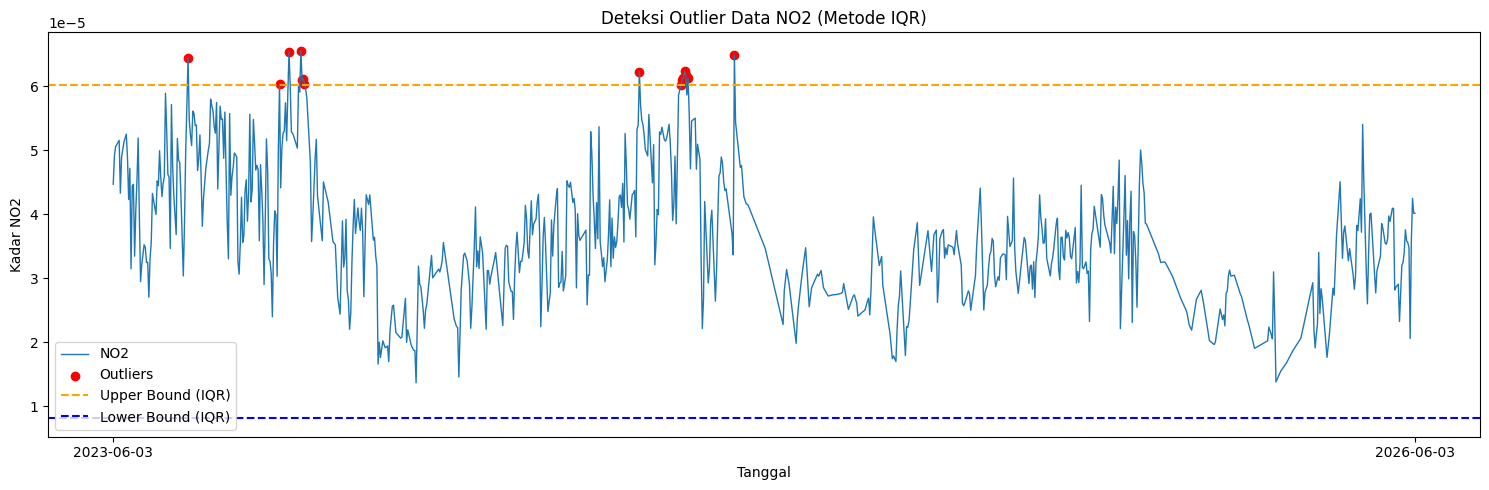

In [18]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

### 12. Penanganan Outlier

Outlier yang terdeteksi tidak langsung dihapus, tetapi diubah menjadi nilai kosong (NaN). Selanjutnya nilai tersebut diisi kembali menggunakan interpolasi linear sehingga pola data tetap terjaga dan tidak menyebabkan kehilangan informasi.

In [19]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 15
Jumlah missing setelah interpolasi: 0


### 13. Visualisasi Data Setelah Interpolasi

Setelah proses pembersihan data selesai dilakukan, grafik kembali ditampilkan untuk memastikan bahwa outlier telah berhasil ditangani dan pola data menjadi lebih stabil.

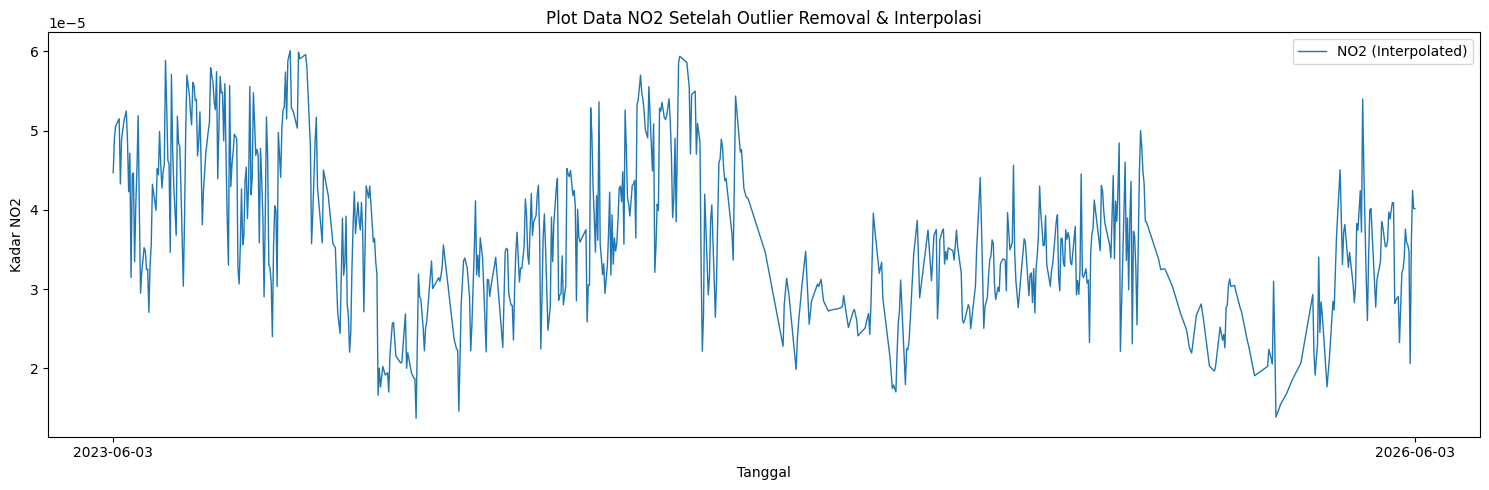

In [20]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

### 14. Analisis Korelasi Data Time Series

Tahap ini digunakan untuk mengetahui hubungan antara data NO₂ pada periode sebelumnya dengan nilai NO₂ pada periode saat ini. Analisis korelasi membantu menentukan jumlah lag yang layak digunakan dalam proses peramalan.

In [21]:
import pandas as pd

def create_supervised(data, n_lag=30):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-30 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised


# Pastikan kolom NO2_scaled ada
# Kalau belum ada, pakai NO2 dulu
supervised_df30 = create_supervised(df['NO2'], n_lag=30)

# Ambil semua lag dan target
lag_cols = supervised_df30.drop(columns='NO2(t)').columns

# Hitung korelasi
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

print(correlations)

NO2(t-30)    0.471372
NO2(t-29)    0.479753
NO2(t-28)    0.478632
NO2(t-27)    0.480872
NO2(t-26)    0.493620
NO2(t-25)    0.505777
NO2(t-24)    0.517467
NO2(t-23)    0.518562
NO2(t-22)    0.527794
NO2(t-21)    0.533427
NO2(t-20)    0.534440
NO2(t-19)    0.535756
NO2(t-18)    0.550856
NO2(t-17)    0.556666
NO2(t-16)    0.558258
NO2(t-15)    0.567845
NO2(t-14)    0.580192
NO2(t-13)    0.591408
NO2(t-12)    0.606232
NO2(t-11)    0.631178
NO2(t-10)    0.638130
NO2(t-9)     0.640451
NO2(t-8)     0.646747
NO2(t-7)     0.669163
NO2(t-6)     0.685445
NO2(t-5)     0.714672
NO2(t-4)     0.727893
NO2(t-3)     0.756653
NO2(t-2)     0.808375
NO2(t-1)     0.885395
dtype: float64


### 15. Normalisasi Data Menggunakan Min-Max Scaling

Normalisasi dilakukan untuk mengubah rentang nilai data menjadi 0 hingga 1. Langkah ini penting karena metode KNN menggunakan perhitungan jarak, sehingga seluruh fitur perlu berada pada skala yang sama.

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print(df.head())

print("\n" + "="*50)
df.info()

        date       NO2  NO2_cleaned  NO2_filled  NO2_scaled
0 2023-06-03  0.000045     0.000045    0.000045    0.598121
1 2023-06-04  0.000049     0.000049    0.000049    0.682902
2 2023-06-05  0.000051     0.000051    0.000051    0.711566
3 2023-06-06  0.000051     0.000051    0.000051    0.717760
4 2023-06-07  0.000051     0.000051    0.000051    0.723954

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1097 non-null   datetime64[ns]
 1   NO2          1097 non-null   float64       
 2   NO2_cleaned  1082 non-null   float64       
 3   NO2_filled   1097 non-null   float64       
 4   NO2_scaled   1097 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 43.0 KB


### 16. Pembentukan Dataset Supervised Learning (Lag 2 Hari)

Data time series diubah menjadi bentuk supervised learning dengan menggunakan 2 hari sebelumnya sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.

In [34]:
supervised_df2 = create_supervised(df['NO2_scaled'], n_lag=2)

print(supervised_df)
print(supervised_df.shape)

      NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4     0.598121  0.682902  0.711566  0.717760  0.723954
5     0.682902  0.711566  0.717760  0.723954  0.730148
6     0.711566  0.717760  0.723954  0.730148  0.570919
7     0.717760  0.723954  0.730148  0.570919  0.678604
8     0.723954  0.730148  0.570919  0.678604  0.701636
...        ...       ...       ...       ...       ...
1092  0.460853  0.427837  0.422464  0.407013  0.133560
1093  0.427837  0.422464  0.407013  0.133560  0.429283
1094  0.422464  0.407013  0.133560  0.429283  0.555287
1095  0.407013  0.133560  0.429283  0.555287  0.510633
1096  0.133560  0.429283  0.555287  0.510633  0.510633

[1093 rows x 5 columns]
(1093, 5)


### 17. Pembentukan Dataset Supervised Learning (Lag 4 Hari)

Data time series diubah menjadi bentuk supervised learning dengan menggunakan 4 hari sebelumnya sebagai fitur untuk memprediksi nilai NO₂ pada hari berikutnya.

In [23]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

      NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4     0.598121  0.682902  0.711566  0.717760  0.723954
5     0.682902  0.711566  0.717760  0.723954  0.730148
6     0.711566  0.717760  0.723954  0.730148  0.570919
7     0.717760  0.723954  0.730148  0.570919  0.678604
8     0.723954  0.730148  0.570919  0.678604  0.701636
...        ...       ...       ...       ...       ...
1092  0.460853  0.427837  0.422464  0.407013  0.133560
1093  0.427837  0.422464  0.407013  0.133560  0.429283
1094  0.422464  0.407013  0.133560  0.429283  0.555287
1095  0.407013  0.133560  0.429283  0.555287  0.510633
1096  0.133560  0.429283  0.555287  0.510633  0.510633

[1093 rows x 5 columns]
(1093, 5)


### 18. Pembentukan Dataset Supervised Learning (Lag 10 Hari)

Pada skenario kedua digunakan 10 hari sebelumnya sebagai fitur prediksi. Tujuannya untuk mengetahui pengaruh penambahan jumlah data historis terhadap performa model.

In [24]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

      NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10     0.598121  0.682902  0.711566  0.717760  0.723954  0.730148  0.570919   
11     0.682902  0.711566  0.717760  0.723954  0.730148  0.570919  0.678604   
12     0.711566  0.717760  0.723954  0.730148  0.570919  0.678604  0.701636   
13     0.717760  0.723954  0.730148  0.570919  0.678604  0.701636  0.724667   
14     0.723954  0.730148  0.570919  0.678604  0.701636  0.724667  0.736736   
...         ...       ...       ...       ...       ...       ...       ...   
1092   0.296895  0.184697  0.269612  0.354527  0.362418  0.392616  0.460853   
1093   0.184697  0.269612  0.354527  0.362418  0.392616  0.460853  0.427837   
1094   0.269612  0.354527  0.362418  0.392616  0.460853  0.427837  0.422464   
1095   0.354527  0.362418  0.392616  0.460853  0.427837  0.422464  0.407013   
1096   0.362418  0.392616  0.460853  0.427837  0.422464  0.407013  0.133560   

      NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10  

### 19. Pembentukan Dataset Supervised Learning (Lag 30 Hari)

Pada skenario ketiga digunakan 30 hari sebelumnya sebagai fitur prediksi. Skenario ini digunakan untuk membandingkan performa model dengan jumlah lag yang lebih besar.

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Pakai data yang sudah dibersihkan dan diinterpolasi
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

print(df[['date', 'NO2', 'NO2_filled', 'NO2_scaled']].head())
df.info()

        date       NO2  NO2_filled  NO2_scaled
0 2023-06-03  0.000045    0.000045    0.667954
1 2023-06-04  0.000049    0.000049    0.762634
2 2023-06-05  0.000051    0.000051    0.794644
3 2023-06-06  0.000051    0.000051    0.801561
4 2023-06-07  0.000051    0.000051    0.808478
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1097 non-null   datetime64[ns]
 1   NO2          1097 non-null   float64       
 2   NO2_cleaned  1082 non-null   float64       
 3   NO2_filled   1097 non-null   float64       
 4   NO2_scaled   1097 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 43.0 KB


### 20. Modeling dan Evaluasi Menggunakan KNN Regression

Tahap ini merupakan proses utama peramalan menggunakan metode K-Nearest Neighbor (KNN) Regression. Data dibagi menjadi data training dan testing dengan rasio 80:20 tanpa proses pengacakan karena data berbentuk time series.

Evaluasi model dilakukan menggunakan tiga metrik yaitu:

- RMSE (Root Mean Squared Error)
- R² Score
- MAPE (Mean Absolute Percentage Error)

Ketiga metrik tersebut digunakan untuk mengukur tingkat kesalahan prediksi dan kemampuan model dalam mengikuti pola data aktual.

In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred

knn_2, y_test_2, y_pred_2 = train_knn(supervised_df2,"KNN - 2 Hari Sebelumnya")
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df4, "KNN - 4 Hari Sebelumnya")
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 2 Hari Sebelumnya ===
Train Size: 876 — Test Size: 219
RMSE: 0.083858
R² Score: 0.7112
MAPE: 80.9587%

=== KNN - 4 Hari Sebelumnya ===
Train Size: 874 — Test Size: 219
RMSE: 0.080522
R² Score: 0.7337
MAPE: 64.4835%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 869 — Test Size: 218
RMSE: 0.094121
R² Score: 0.6362
MAPE: 71.0031%

=== KNN - 30 Hari Sebelumnya ===
Train Size: 853 — Test Size: 214
RMSE: 0.000005
R² Score: 0.4629
MAPE: 17.5753%


### 21. Visualisasi Hasil Prediksi Lag 2 Hari

Grafik berikut menampilkan perbandingan antara nilai aktual dan nilai hasil prediksi menggunakan model KNN Regression dengan lag 2 hari sebelumnya.

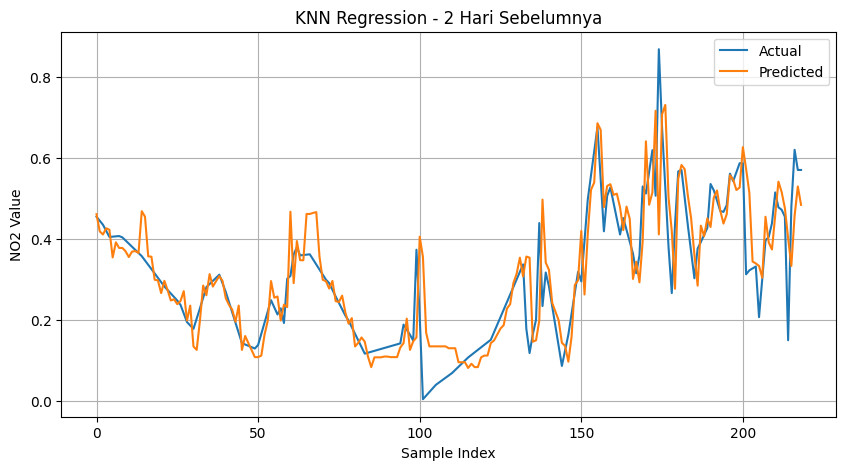

In [36]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(len(y_test_2)), y_test_2, label="Actual")
plt.plot(np.arange(len(y_pred_2)), y_pred_2, label="Predicted")

plt.title("KNN Regression - 2 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.grid(True)

plt.show()

### 22. Visualisasi Hasil Prediksi Lag 4 Hari

Grafik berikut menampilkan perbandingan antara nilai aktual dan nilai hasil prediksi menggunakan model KNN Regression dengan lag 4 hari sebelumnya.

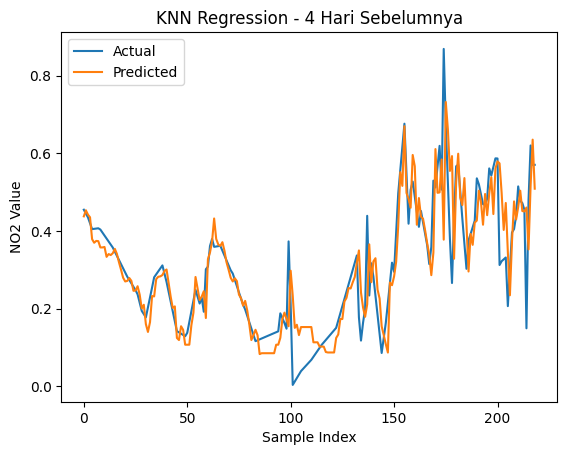

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### 23. Visualisasi Hasil Prediksi Lag 10 Hari

Grafik berikut menampilkan hasil prediksi menggunakan 10 hari sebelumnya sebagai fitur masukan. Perbandingan dilakukan untuk melihat kemampuan model dalam mengikuti pola data aktual.

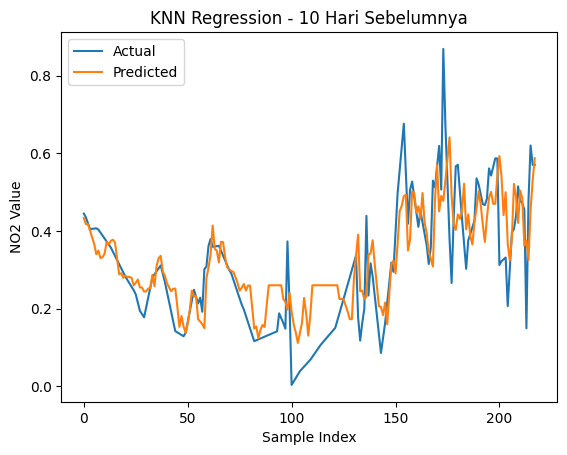

In [31]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### 24. Visualisasi Hasil Prediksi Lag 30 Hari

Grafik berikut menunjukkan hasil prediksi menggunakan 30 hari sebelumnya sebagai fitur masukan. Hasil ini dibandingkan dengan skenario sebelumnya untuk menentukan jumlah lag yang menghasilkan performa terbaik.

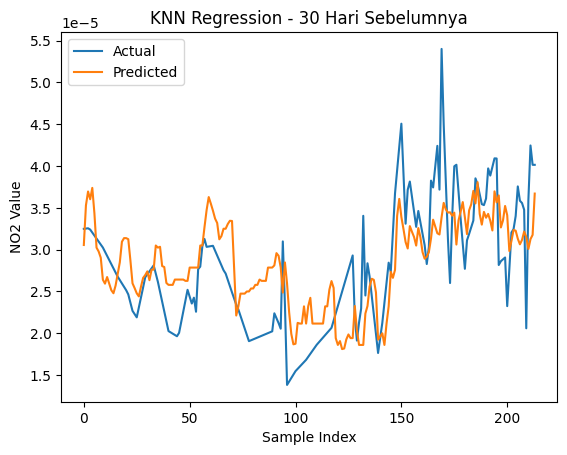

In [32]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### ### 25. Prediksi Nilai NO₂ untuk Hari Berikutnya

Setelah model KNN Regression selesai dilatih, langkah selanjutnya adalah melakukan prediksi nilai NO₂ untuk hari berikutnya. Prediksi dilakukan dengan menggunakan beberapa nilai NO₂ terakhir sebagai data masukan (input) sesuai dengan jumlah lag yang digunakan pada model.

Pada model lag 2 hari, sistem mengambil dua nilai NO₂ terakhir dari dataset yang telah dinormalisasi. Nilai tersebut kemudian dibentuk menjadi satu baris data (feature vector) yang sesuai dengan format input model KNN. Selanjutnya model melakukan prediksi terhadap nilai NO₂ pada hari berikutnya.

Karena hasil prediksi masih berada dalam bentuk data yang telah dinormalisasi (skala 0–1), maka dilakukan proses inverse transform menggunakan MinMaxScaler untuk mengembalikan nilai prediksi ke satuan NO₂ asli. Hasil akhir menunjukkan estimasi kadar NO₂ untuk satu hari setelah data terakhir yang tersedia.

Hasil prediksi menggunakan model lag 2 hari adalah sebesar **4.0233 × 10⁻⁵ mol/m²**.

Selanjutnya dilakukan prediksi menggunakan model lag 4 hari. Pada model ini digunakan empat nilai NO₂ terakhir sebagai fitur masukan. Proses prediksi dilakukan dengan langkah yang sama, yaitu membentuk data input, melakukan prediksi menggunakan model KNN, dan mengembalikan hasil prediksi ke skala asli menggunakan inverse transform.

Hasil prediksi menggunakan model lag 4 hari adalah sebesar **3.8827 × 10⁻⁵ mol/m²**.

Perbedaan hasil prediksi antara lag 2 dan lag 4 terjadi karena jumlah data historis yang digunakan sebagai acuan model berbeda. Model dengan performa evaluasi terbaik (RMSE lebih kecil dan R² lebih tinggi) dapat dipilih sebagai model utama untuk melakukan prediksi nilai NO₂ pada hari berikutnya.


In [37]:
last_data = df['NO2_scaled'].tail(2).values

In [38]:
X_next = last_data.reshape(1, -1)

In [39]:
pred_next_scaled = knn_2.predict(X_next)

In [40]:
pred_next = scaler.inverse_transform(
    pred_next_scaled.reshape(-1,1)
)

print("Prediksi NO2 Besok:")
print(pred_next[0][0])

Prediksi NO2 Besok:
4.0233187800000004e-05


In [41]:
last_data = df['NO2_scaled'].tail(4).values

X_next = last_data.reshape(1, -1)

pred_next_scaled = knn_4.predict(X_next)

pred_next = scaler.inverse_transform(
    pred_next_scaled.reshape(-1,1)
)

print("Prediksi NO2 Besok =", pred_next[0][0])

Prediksi NO2 Besok = 3.88274098e-05


### Kesimpulan

Berdasarkan hasil peramalan kadar NO₂ di wilayah Jombang menggunakan metode KNN Regression, dapat disimpulkan bahwa model mampu mempelajari pola historis data dan menghasilkan prediksi terhadap nilai NO₂ pada periode berikutnya.

Pengujian dilakukan menggunakan tiga skenario lag, yaitu 4 hari, 10 hari, dan 30 hari sebelumnya. Performa model dievaluasi menggunakan RMSE, R² Score, dan MAPE. Hasil evaluasi menunjukkan bahwa jumlah lag yang digunakan berpengaruh terhadap kualitas prediksi yang dihasilkan.

Visualisasi antara nilai aktual dan nilai prediksi menunjukkan bahwa model mampu mengikuti pola umum pergerakan data NO₂ meskipun masih terdapat beberapa deviasi pada titik-titik tertentu. Oleh karena itu, metode KNN Regression dapat digunakan sebagai salah satu pendekatan untuk peramalan kualitas udara berbasis data time series.